# 9. MCH geneflank

Part of the **[Fig. 3 chapter](fig3.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{indir}scATAC/celltypes.txt.gz'`  ·  _scATAC peaks_
- `f'{indir}scATAC/peak/peaklist.txt'`  ·  _scATAC peaks_
- `f'{indir}scATAC/cCREs.bed.gz'`  ·  _scATAC peaks_
- `f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.{ct}.CHN-both.hdf'`  ·  _other_
- `f'{outdir}cCREs_distal2k.bed'`  ·  _other_
- `f'{outdir}cCREs_distal25k.bed'`  ·  _other_
- `f'{outdir}{peak_ct}.bed'`  ·  _other_
- `f'{indir}scATAC/atac2majortype.tsv'`  ·  _scATAC peaks_
- `f'{outdir}cCREs_distal2k.split{split}.slop{ws}b.{w}b.{bw_ct}.CHN-both.hdf'`  ·  _other_
- `f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.hdf'`  ·  _other_
- `f'{indir}scRNA/pseudobulk/L1/L1.hdf'`  ·  _scRNA/expr_
- `f'{outdir}gene.split{split}.slop{dist}b.{ws}b.{ct}.{context}.hdf'`  ·  _other_
- `f'{outdir}tss.split{split}.slop{dist}b.{ws}b.{ct}.{context}.hdf'`  ·  _other_
- `f'{bed_dir}{bed}.bed'`  ·  _other_
- `f'{bed_dir}{ct}.{bed}.CHN-both.tsv'`  ·  _table_
- `f'{bed_dir}{ct}.CHN-both.hdf'`  ·  _other_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [ ]:
import os
import time
import numpy as np
import pandas as pd
from glob import glob
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

import cooler
import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.mcds import MCDS
from ALLCools.integration.seurat_class import SeuratIntegration

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [ ]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [ ]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [ ]:
def expand_bed(input_file, window_size, window, split, min_split_size):

    dist = window_size * window
    dist_str = num2str(dist)
    ws_str = num2str(window_size)
    bed = pd.read_csv(input_file, sep='\t', header=None, index_col=None, usecols=[0,1,2], names=['chrom', 'start', 'end'])
    bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]

    if split==0:
        mid = ((bed['start'] + bed['end']) // 2).astype(int)
        bed['start'], bed['end'] = mid.copy(), mid.copy()
    bed['start'] = bed['start'] - dist
    bed['end'] = bed['end'] + dist
    bed = bed.loc[(bed['start']>0) & (bed['end']<bed['chrom'].map(chrom_sizes))]
    
    bed_new = []
    for idx,xx,yy,zz in bed.reset_index().values:
        if split>0:
            split_size = (zz-yy-2*dist) / split
            if split_size<min_split_size:
                continue
        for i in range(window):
            bed_new.append([xx, yy+window_size*i, yy+window_size*(i+1), f'{idx}_{i}'])
        # if (yy+dist)<(zz-dist):
        #     bed_new.append([xx, yy+dist, zz-dist])
        if split>0:
            for i in range(split):
                bed_new.append([xx, yy+dist+split_size*i, yy+dist+split_size*(i+1), f'{idx}_{window+i}'])
        for i in range(window):
            bed_new.append([xx, zz-dist+window_size*i, zz-dist+window_size*(i+1), f'{idx}_{window+split+i}'])

    print(len(bed_new))
    bed_new = pd.DataFrame(bed_new)
    bed_new[[1,2]] = np.around(bed_new[[1,2]], decimals=0).astype(int)
    bed_new.to_csv(input_file.replace('.bed',f'.split{split}.slop{dist_str}b.{ws_str}b.bed'), sep='\t', header=False, index=False)
    return dist_str, ws_str


In [ ]:
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}m'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str
        
def generate_flankmap(peak_group, mc_group, window_size=500, window=50, split=0, min_split_size=1):
    global context
    dist = window_size * window
    dist_str = num2str(dist)
    ws_str = num2str(window_size)
    # dist_str, ws_str = expand_bed(f'{peak_group}.bed', window_size=window_size, window=window, split=split, min_split_size=min_split_size)
    # time.sleep(3)
    cmd = f'bigWigAverageOverBed {mc_group}.{context}.frac.bw {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.bed {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.{mc_group.split("/")[-1]}.{context}.tsv'
    os.system(cmd)
    return


In [ ]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/mCH_geneflank/'


In [ ]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [ ]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta = gene_meta.loc[gene_meta['chrom'].isin(chrom_sizes.index)]
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]


In [ ]:
ens2gene = gene_meta.set_index('gene_id_idx')['gene_name'].to_dict()
gene2ens = gene_meta.set_index('gene_name')['gene_id_idx'].to_dict()


In [ ]:
gene_meta['TSS'] = gene_meta['start'].copy()
selg = (gene_meta['strand']=='-')
gene_meta.loc[selg, 'TSS'] = gene_meta.loc[selg, 'end']

gene_meta['TES'] = gene_meta['start'].copy()
selg = (gene_meta['strand']=='+')
gene_meta.loc[selg, 'TES'] = gene_meta.loc[selg, 'end']

gene_meta['length'] = gene_meta['end'] - gene_meta['start']


In [ ]:
gene_meta[['TSS', 'TES', 'strand']]

In [ ]:
tmp = gene_meta.set_index('gene_id_idx')
# sns.histplot(tmp['length'], bins=100, log_scale=(10, None))

In [ ]:
## write gene bed
tmp[['chrom', 'start', 'end', 'gene_name', 'strand']].sort_values(by=['chrom', 'start', 'end']).reset_index()[['chrom', 'start', 'end', 'gene_id_idx', 'gene_name', 'strand']].to_csv(f'{outdir}gene.bed', sep='\t', index=False, header=False)


In [ ]:
## write tss bed
tmp[['chrom', 'TSS', 'gene_name', 'strand']].sort_values(by=['chrom', 'TSS']).reset_index()[['chrom', 'TSS', 'TSS', 'gene_id_idx', 'gene_name', 'strand']].to_csv(f'{outdir}tss.bed', sep='\t', index=False, header=False)


In [ ]:
## write tes bed
tmp[['chrom', 'TES', 'gene_name', 'strand']].sort_values(by=['chrom', 'TES']).reset_index()[['chrom', 'TES', 'TES', 'gene_id_idx', 'gene_name', 'strand']].to_csv(f'{outdir}tes.bed', sep='\t', index=False, header=False)


In [ ]:
import scipy.io as sio

peak_matrix = sio.mmread(f'{indir}scATAC/matrix.tsv.gz')


In [ ]:
atac_ct_list = pd.read_csv(f'{indir}scATAC/celltypes.txt.gz', index_col=0, header=None).index
selct = pd.read_csv(f'{indir}scATAC/peak/peaklist.txt', sep='.', index_col=0, header=None).index
selct = atac_ct_list[atac_ct_list.isin(selct)]
print(selct.shape[0])


In [ ]:
peak = pd.read_csv(f'{indir}scATAC/cCREs.bed.gz', sep='\t', names=['chrom','start','end'], 
                   header=None, index_col=None)


In [ ]:
peak_matrix = peak_matrix.tocsr()[:, atac_ct_list.isin(selct)]
selp = peak_matrix.getnnz(axis=1)>0
peak = peak.loc[selp]
peak_matrix = peak_matrix[selp]


In [ ]:
peak.to_csv(f'{indir}scATAC/cCREs_selct.bed.gz', sep='\t', header=False, index=False)


In [ ]:
# dmr_list = np.sort(glob(f'{outdir}*gene.bed'))
# dmr_list = np.sort([xx.replace('.bed', '') for xx in dmr_list])
dmr_list = np.array([f'{outdir}gene', 
                     f'{outdir}tss', 
                     f'{outdir}tes', 
                     f'{outdir}CGI',
                     f'{outdir}cCREs_distal2k',
                    ])

# bw_list = glob(f'{indir}merged_allc/L1/CHN/c*.frac.bw')
bw_list = glob(f'{indir}merged_allc/L1/CHN/c*.frac.bw')
bw_list = np.sort([xx.replace(f'.{context}.frac.bw', '') for xx in bw_list])

print(dmr_list, bw_list)


In [ ]:
context = 'CGN-Merge'


In [ ]:
cpu = 20
w = 50
split = 0
# peak_ct = dmr_list[1]
ws = 50
context = 'CHN-both'
# context = 'CGN-Merge'

with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    # for ws in [500, 10000]:
    for peak_ct in dmr_list[1:3]:
        # expand_bed(f'{peak_ct}.bed', window_size=ws, window=w, split=split, min_split_size=1)
        for mc_ct in bw_list:
            future = executor.submit(
                generate_flankmap,
                peak_group=peak_ct,
                mc_group=mc_ct,
                window_size=ws, window=w, split=split, min_split_size=1
            )
            futures[future] = f'{peak_ct.split("/")[-1]}-{mc_ct.split("/")[-1]}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [ ]:
def save_hdf(peak_ct, mc_ct, ws, w, split):
    data = pd.read_csv(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.{context}.tsv', sep='\t', header=None, index_col=0)
    selr = data.index.str.split('_').str[0].astype(int).unique()
    region_tmp = region.iloc[selr]
    ratio = data[5].values.reshape((-1, 100+split))
    cov = data[2].values.reshape((-1, 100+split))
    ratio[cov==0] = np.nan
    selr = (region_tmp[5]=='-')
    ratio[selr] = ratio[selr, ::-1]
    ratio = pd.DataFrame(ratio, index=region_tmp.index)
    ratio.to_hdf(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.{context}.hdf', key='data')
    return


In [ ]:
outdir

In [ ]:
# region = pd.read_csv(f'{peak_ct}.bed', sep='\t', header=None, index_col=3)
# xx = bw_list[3]
# mc_ct = xx.split('/')[-1]
w = 50
split = 0
ws = 50
cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    # for ws in [500, 10000]:
    # for peak_ct,split in zip(dmr_list[:2], [0,50]):
    for peak_ct in dmr_list[1:3]:
        # region = pd.read_csv(f'{peak_ct}.bed', sep='\t', header=None, index_col=None) ## For peak
        # region[5] = '+'
        region = pd.read_csv(f'{peak_ct}.bed', sep='\t', header=None, index_col=None) ## For gene
        region = region.set_index(3)
        # xx = bw_list[3]
        for xx in bw_list:
            mc_ct = xx.split('/')[-1]
            future = executor.submit(
                save_hdf,
                peak_ct=peak_ct,
                mc_ct=mc_ct,
                ws=ws, 
                w=w, 
                split=split, 
            )
            futures[future] = f'{mc_ct}-{peak_ct.split("/")[-1]}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [ ]:
# import pyBigWig

# global_ch = []
# for ct in L1_meta.index:
#     bw_file = f'{indir}merged_allc/L1/CHN/{ct}.CHN-both.frac.bw'
#     bw = pyBigWig.open(bw_file)
#     info = bw.header()
#     global_ch.append(info['sumData']/info['nBasesCovered'])
    
# global_ch = pd.Series(global_ch, index=L1_meta.index)


In [ ]:
leg_order = ['c10', 'c16', 'c14', 'c31', 'c2', 'c5', 
             'c22', 'c9', 'c26', 'c3', 'c13', 'c12', 'c32', 'c27', 'c33', 
             'c30', 'c24', 'c4', 'c0', 'c20', 'c18', 
             'c29', 'c17', 'c28', 'c34', 'c19', 'c11', 'c21', 
             'c25', 'c6', 'c23', 'c15', 'c1', 'c8', 'c7']

In [ ]:
split = 0
ws = '2k'
w = '50'
peak_ct = 'cCREs_distal2k'
region = pd.read_csv(f'{outdir}{peak_ct}.bed', sep='\t', header=None, index_col=None)
selp = peak.reset_index(drop=True).reset_index().set_index(['chrom','start']).loc[region.set_index([0,1]).index, 'index'].values
peak_matrix = peak_matrix[selp]


In [ ]:
peak_matrix


In [ ]:
from scipy.sparse import save_npz
peak_matrix = peak_matrix.astype(int)
save_npz(f'{outdir}cCREs_distal2k_104celltype.npz', peak_matrix)

In [ ]:
atac2mt = pd.read_csv(f'{indir}scATAC/atac2majortype.tsv', sep='\t', header=None, index_col=None)
atac2mt = atac2mt.loc[~atac2mt[1].isna()]
atac2mt.loc[atac2mt[1]=='Hema Bmem', 1] = 'Hema B' 

In [ ]:
mt2atac = {xx:[] for xx in L1_meta['L1_abbr']}
for xx,yy in atac2mt.values:
    for y in yy.split(','):
        mt2atac[y].append(xx)
    

In [ ]:
selct = pd.Series(np.arange(len(selct)), index=selct)

In [ ]:
ctcre = {}
for ct in L1_meta.index:
    ctname = L1_annot[ct]
    if len(mt2atac[ctname])>0:
        selp = peak_matrix[:, selct.loc[mt2atac[ctname]]].getnnz(axis=1)>0
        ctcre[ct] = pd.Series(selp, index=np.arange(region.shape[0]))
    # else:
    #     ctcre[ct] = pd.Series(False, index=np.arange(region.shape[0]))
        

In [ ]:
# split = 0
# ws = '25k'
# w = '500'

# data_all = []
# for peak_ct in ['tss', 'tes', 'CGI', 'cCREs_distal2k']:
#     data = []
#     for i,ct in enumerate(L1_meta.index):
#         ratio = pd.read_hdf(f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.{ct}.CHN-both.hdf', key='data')
#         selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
#         ratio = ratio.loc[selr]
#         tmp = np.nanmean(ratio, axis=0)
#         data.append(tmp)
#     data = pd.DataFrame(data, index=L1_meta.index)
#     data.to_hdf(f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.hdf', key='data')
#     data_all.append(data.loc[leg_order])


In [ ]:
# fig, axes = plt.subplots(35, 35, figsize=(12,12), dpi=300, 
#                          gridspec_kw={'wspace':0, 'hspace':0})
# ax = axes[0,0]
bw_ct = 'c33'
ratio = pd.read_hdf(f'{outdir}cCREs_distal2k.split{split}.slop{ws}b.{w}b.{bw_ct}.CHN-both.hdf', key='data')
selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
ratio = ratio.loc[selr]
ave, std = np.nanmean(ratio), np.nanstd(ratio)
ratio = (ratio - ave) / std
ratio = ratio.iloc[np.argsort(np.nanmean(ratio, axis=1))]
selp = ctcre[peak_ct].loc[ratio.index]
tmp = ratio.loc[selp]

fig, ax = plt.subplots(dpi=300)
ax.imshow(np.clip(tmp, a_min=np.percentile(tmp, 5), a_max=np.percentile(tmp, 50)), 
          cmap='Purples_r', aspect='auto', vmin=-0.5, vmax=0, rasterized=True)


In [ ]:
split = 0
ws = '2k'
w = '50'

data = []
for i,bw_ct in enumerate(L1_meta.index):
    ratio = pd.read_hdf(f'{outdir}cCREs_distal2k.split{split}.slop{ws}b.{w}b.{bw_ct}.CHN-both.hdf', key='data')
    # selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
    # ratio = ratio.loc[selr]
    # ave, std = np.nanmean(ratio), np.nanstd(ratio)
    # ratio = (ratio - ave) / std
    # ratio = ratio.iloc[np.argsort(np.nanmean(ratio, axis=1))]
    data_tmp = []
    for j,peak_ct in enumerate(ctcre):
        selp = ctcre[peak_ct].loc[ratio.index]
        tmp = ratio.loc[selp]
        tmp = np.nanmean(tmp, axis=0)
        data_tmp.append(tmp)
    data_tmp = pd.DataFrame(data_tmp, index=ctcre.keys())
    data_tmp = (data_tmp - data_tmp.values.min()) / (data_tmp.values.max() - data_tmp.values.min())
    data.append(data_tmp)
    print(bw_ct)
    
data = pd.concat(data, axis=1)
data.columns = np.arange(data.shape[1])
data.to_hdf(f'{outdir}cCREs_distal2k.split{split}.slop{ws}b.{w}b.celltype.hdf', key='data')


In [ ]:
split = 0
ws = '2k'
w = '50'

# data_all = []
for peak_ct in ['cCREs_distal2k']:
    data = []
    for i,ct in enumerate(L1_meta.index):
        ratio = pd.read_hdf(f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.{ct}.CHN-both.hdf', key='data')
        selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
        ratio = ratio.loc[selr]
        if peak_ct=='cCREs_distal2k':
            if ct in ctcre:
                selp = ctcre[ct].loc[ratio.index]
            else:
                selp = pd.Series(False, index=ratio.index)
            tmp = np.concatenate([np.nanmean(ratio.loc[selp], axis=0), 
                                  np.nanmean(ratio.loc[~selp], axis=0)])
        else:
            tmp = np.nanmean(ratio, axis=0)
        data.append(tmp)
    data = pd.DataFrame(data, index=L1_meta.index)
    if peak_ct=='cCREs_distal2k':
        data.columns = data.columns - 100
        data.iloc[:, :ratio.shape[1]].to_hdf(f'{outdir}{peak_ct}_on.split{split}.slop{ws}b.{w}b.hdf', key='data')
        data.iloc[:, ratio.shape[1]:].to_hdf(f'{outdir}{peak_ct}_off.split{split}.slop{ws}b.{w}b.hdf', key='data')
        # data_all.append(data.loc[leg_order])
        # data_all.append(data.loc[leg_order])
    else:
        data.to_hdf(f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.hdf', key='data')
        # data_all.append(data.loc[leg_order])


In [ ]:
from scipy.stats import zscore
split = 0
ws = '2k'
w = '50'
data = pd.concat([pd.read_hdf(f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.hdf', key='data') for peak_ct in ['tss', 'tes', 'CGI', 'cCREs_distal2k_on', 'cCREs_distal2k_off']], axis=1).loc[leg_order]
selc = (data.columns>=0)
ave = np.nanmean(data.loc[:, selc], axis=1)[:,None]
std = np.nanstd(data.loc[:, selc], axis=1)[:,None]
cg = sns.clustermap(# data/global_ch.loc[data.index].values[:,None], 
                   (data-ave)/std,
                   cmap='Purples_r', 
                   row_cluster=False, 
                   col_cluster=False, 
                   yticklabels=data.index.map(L1_annot),
                   metric='cosine',
                   vmin=-4, vmax=2
                  )
# rorder = cg.dendrogram_row.reordered_ind.copy()


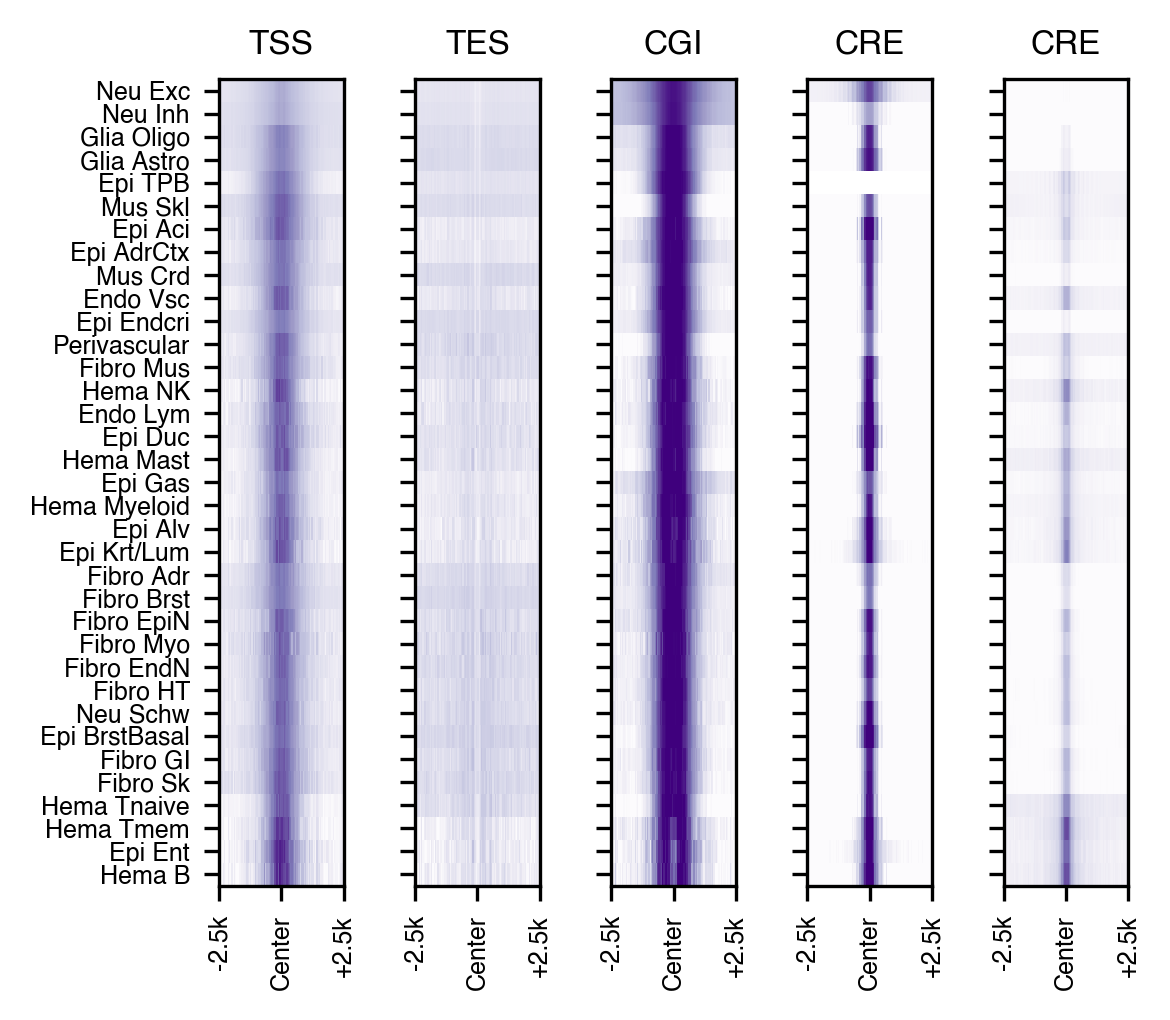

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(4,3.5), dpi=300, sharey='all')
for i in range(5):
    ax = axes[i]
    tmp = (data.iloc[:, (i*100):((i+1)*100)] - ave)/std
    ax.imshow(tmp, cmap='Purples_r', aspect='auto', vmin=-3, vmax=1, 
              rasterized=True, interpolation='none')
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(pd.Index(leg_order).map(L1_annot), fontsize=6)
    ax.set_xticks([-0.5, 49.5, 99.5])
    ax.set_xticklabels(['-2.5k', 'Center', '+2.5k'], fontsize=6, rotation=90)
    ax.set_title(['TSS', 'TES', 'CGI', 'CRE', 'CRE'][i], fontsize=8)
    
fig.tight_layout()
fig.savefig(f'mCH_geneflank/L1_annot_mCH_heatmap.pdf', transparent=True)


In [ ]:
split = 0
ws = '2k'
w = '50'
data = pd.concat([pd.read_hdf(f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.hdf', key='data') for peak_ct in ['tss', 'tes', 'CGI', 'cCREs_distal2k']], axis=1).loc[leg_order]
cg = sns.clustermap(# data/global_ch.loc[data.index].values[:,None], 
                   zscore(data, axis=1),
                   cmap='Purples_r', 
                   row_cluster=False, 
                   col_cluster=False, 
                   yticklabels=data.index.map(L1_annot),
                   metric='cosine',
                   # vmin=0.6, vmax=1.0
                  )
# rorder = cg.dendrogram_row.reordered_ind.copy()


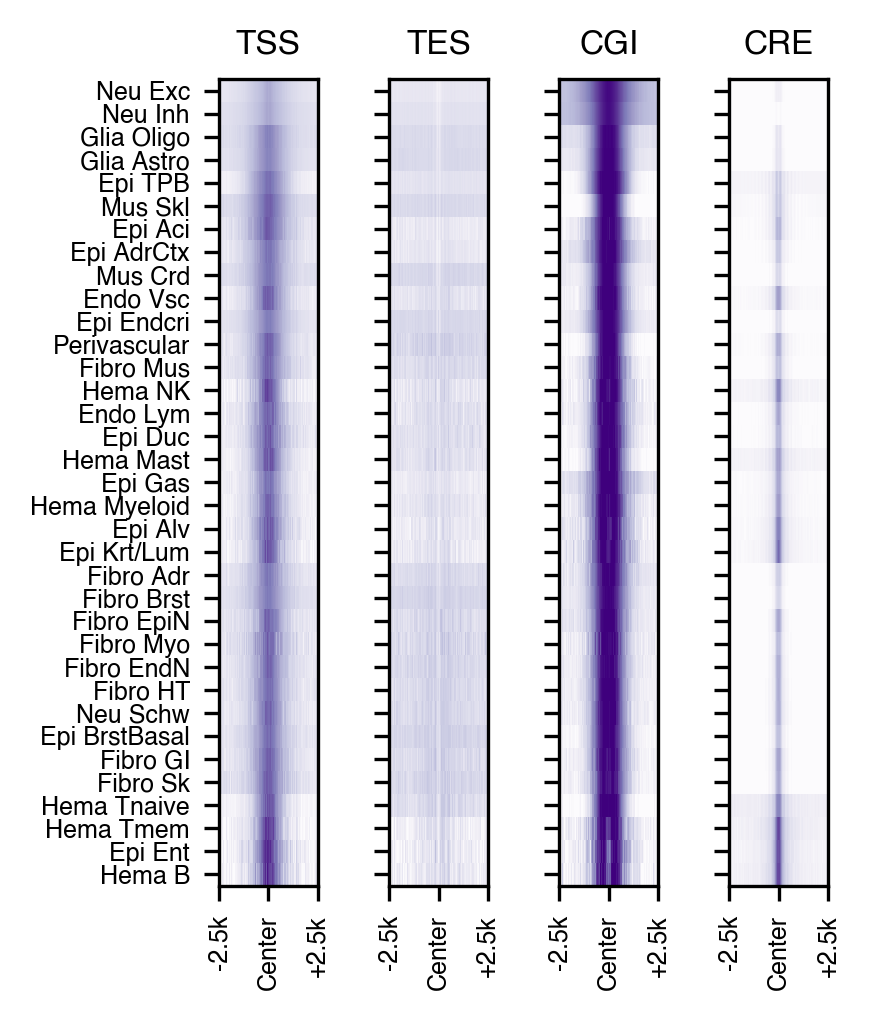

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(3,3.5), dpi=300, sharey='all')
for i in range(4):
    ax = axes[i]
    tmp = zscore(data, axis=1).iloc[:, (i*100):((i+1)*100)]
    ax.imshow(tmp, cmap='Purples_r', aspect='auto', vmin=-3, vmax=1, rasterized=True, interpolation='none')
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(pd.Index(leg_order).map(L1_annot), fontsize=6)
    ax.set_xticks([-0.5, 49.5, 99.5])
    ax.set_xticklabels(['-2.5k', 'Center', '+2.5k'], fontsize=6, rotation=90)
    ax.set_title(['TSS', 'TES', 'CGI', 'CRE'][i], fontsize=8)
    
fig.tight_layout()
fig.savefig(f'mCH_geneflank/L1_annot_mCH_heatmap.pdf', transparent=True)


In [ ]:
split = 50
dist = '500k'
ws = '10k'
expr = pd.read_hdf(f'{indir}scRNA/pseudobulk/L1/L1.hdf', key='data')


In [ ]:
context = 'CGN-Merge'
data_all = {}
for ct in L1_meta.index:
    ct_name = L1_annot[ct]
    if ct_name in expr.columns:
        ratio = pd.read_hdf(f'{outdir}gene.split{split}.slop{dist}b.{ws}b.{ct}.{context}.hdf')
        selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
        ratio = ratio.loc[selr]
        selg = expr.index[expr.index.isin(ratio.index)]
        tmp = expr.loc[selg, ct_name]
        tmp = tmp[tmp>0]
        gene_group = pd.Series(0, index=selg)
        gene_group.loc[tmp.index] = pd.qcut(tmp, 4, labels=[1,2,3,4]).astype(int)
        data = ratio.groupby(gene_group).mean()
        data_all[ct] = data.values.flatten()
    
data_all = pd.DataFrame(data_all).T
data_all.index = data_all.index.map(L1_annot)


In [ ]:
from scipy.stats import zscore

cg = sns.clustermap(zscore(data_all, axis=1), metric='cosine', cmap='Blues_r', 
                    col_cluster=False, yticklabels=1, vmax=0.5, vmin=-2)
for i in range(4):
    cg.ax_heatmap.plot([150*(i+1), 150*(i+1)], [0, data_all.shape[0]], 'k')

cg.ax_heatmap.plot([0, data_all.shape[1]], [0, 0], 'k')
cg.ax_heatmap.plot([0, data_all.shape[1]], [data_all.shape[0], data_all.shape[0]], 'k')
cg.ax_heatmap.plot([0, 0], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.plot([data_all.shape[1], data_all.shape[1]], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.set_xticks(np.arange(0,data_all.shape[1]+1,50))
cg.ax_heatmap.set_xticklabels(list(np.tile([dist, 'TSS', 'TES'], 5)) + [dist])


In [ ]:
context = 'CHN-both'
data_all = {}
for ct in L1_meta.index:
    ct_name = L1_annot[ct]
    if ct_name in expr.columns:
        ratio = pd.read_hdf(f'{outdir}gene.split{split}.slop{dist}b.{ws}b.{ct}.{context}.hdf')
        selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
        ratio = ratio.loc[selr]
        selg = expr.index[expr.index.isin(ratio.index)]
        tmp = expr.loc[selg, ct_name]
        tmp = tmp[tmp>0]
        gene_group = pd.Series(0, index=selg)
        gene_group.loc[tmp.index] = pd.qcut(tmp, 4, labels=[1,2,3,4]).astype(int)
        data = ratio.groupby(gene_group).mean()
        data_all[ct] = data.values.flatten()
    
data_all = pd.DataFrame(data_all).T
data_all.index = data_all.index.map(L1_annot)


In [ ]:
from scipy.stats import zscore

cg = sns.clustermap(zscore(data_all, axis=1), metric='cosine', cmap='Purples_r', 
                    col_cluster=False, yticklabels=1, vmax=2, vmin=-6)
for i in range(4):
    cg.ax_heatmap.plot([150*(i+1), 150*(i+1)], [0, data_all.shape[0]], 'k')

cg.ax_heatmap.plot([0, data_all.shape[1]], [0, 0], 'k')
cg.ax_heatmap.plot([0, data_all.shape[1]], [data_all.shape[0], data_all.shape[0]], 'k')
cg.ax_heatmap.plot([0, 0], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.plot([data_all.shape[1], data_all.shape[1]], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.set_xticks(np.arange(0,data_all.shape[1]+1,50))
cg.ax_heatmap.set_xticklabels(list(np.tile([dist, 'TSS', 'TES'], 5)) + [dist])


In [ ]:
split = 0
dist = '2k'
ws = '50'
expr = pd.read_hdf(f'{indir}scRNA/pseudobulk/L1/L1.hdf', key='data')


In [ ]:
context = 'CGN-Merge'
data_all = {}
for ct in L1_meta.index:
    ct_name = L1_annot[ct]
    if ct_name in expr.columns:
        ratio = pd.read_hdf(f'{outdir}tss.split{split}.slop{dist}b.{ws}b.{ct}.{context}.hdf')
        selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
        ratio = ratio.loc[selr]
        selg = expr.index[expr.index.isin(ratio.index)]
        tmp = expr.loc[selg, ct_name]
        tmp = tmp[tmp>0]
        gene_group = pd.Series(0, index=selg)
        gene_group.loc[tmp.index] = pd.qcut(tmp, 4, labels=[1,2,3,4]).astype(int)
        data = ratio.groupby(gene_group).mean()
        data_all[ct] = data.values.flatten()
    
data_all = pd.DataFrame(data_all).T
data_all.index = data_all.index.map(L1_annot)


In [ ]:
from scipy.stats import zscore

cg = sns.clustermap(zscore(data_all, axis=1), metric='cosine', cmap='Blues_r', 
                    col_cluster=False, yticklabels=1, vmax=0, vmin=-2)
for i in range(4):
    cg.ax_heatmap.plot([100*(i+1), 100*(i+1)], [0, data_all.shape[0]], 'k')

cg.ax_heatmap.plot([0, data_all.shape[1]], [0, 0], 'k')
cg.ax_heatmap.plot([0, data_all.shape[1]], [data_all.shape[0], data_all.shape[0]], 'k')
cg.ax_heatmap.plot([0, 0], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.plot([data_all.shape[1], data_all.shape[1]], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.set_xticks(np.arange(0,data_all.shape[1]+1,50))
cg.ax_heatmap.set_xticklabels(list(np.tile([dist, 'TSS'], 5)) + [dist])


In [ ]:
context = 'CHN-both'
data_all = {}
for ct in L1_meta.index:
    ct_name = L1_annot[ct]
    if ct_name in expr.columns:
        ratio = pd.read_hdf(f'{outdir}tss.split{split}.slop{dist}b.{ws}b.{ct}.{context}.hdf')
        selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
        ratio = ratio.loc[selr]
        selg = expr.index[expr.index.isin(ratio.index)]
        tmp = expr.loc[selg, ct_name]
        tmp = tmp[tmp>0]
        gene_group = pd.Series(0, index=selg)
        gene_group.loc[tmp.index] = pd.qcut(tmp, 4, labels=[1,2,3,4]).astype(int)
        data = ratio.groupby(gene_group).mean()
        data_all[ct] = data.values.flatten()
    
data_all = pd.DataFrame(data_all).T
data_all.index = data_all.index.map(L1_annot)


In [ ]:
from scipy.stats import zscore

cg = sns.clustermap(zscore(data_all, axis=1), metric='cosine', cmap='Purples_r', 
                    col_cluster=False, yticklabels=1, vmax=1, vmin=-3)
for i in range(4):
    cg.ax_heatmap.plot([100*(i+1), 100*(i+1)], [0, data_all.shape[0]], 'k')

cg.ax_heatmap.plot([0, data_all.shape[1]], [0, 0], 'k')
cg.ax_heatmap.plot([0, data_all.shape[1]], [data_all.shape[0], data_all.shape[0]], 'k')
cg.ax_heatmap.plot([0, 0], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.plot([data_all.shape[1], data_all.shape[1]], [0, data_all.shape[0]], 'k')
cg.ax_heatmap.set_xticks(np.arange(0,data_all.shape[1]+1,50))
cg.ax_heatmap.set_xticklabels(list(np.tile([dist, 'TSS'], 5)) + [dist])


In [ ]:
peak_ct = 'gene'
split = 50
ws = '500k'
w = '10k'

fig, axes = plt.subplots(6, 6, figsize=(12, 6), dpi=300, sharex='all')
for i,ct in enumerate(L1_meta.index):
    ax = axes.flatten()[i]
    if ct=='c11':
        ax.axis('off')
        continue
    ratio = pd.read_hdf(f'{outdir}{peak_ct}.split{split}.slop{ws}b.{w}b.{ct}.CHN-both.hdf', key='data')
    selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
    ratio = ratio.loc[selr]
    idx = np.arange(ratio.shape[1])
    tmp = np.nanmean(ratio, axis=0)
    ax.plot(idx, tmp, color=L1_color[ct], linewidth=0.5)
    ax.set_title(L1_annot[ct])
    ax.set_xticks([0, 50, 50+split, 100+split])
    ax.set_xticklabels([f'-{ws}', 'TSS', 'TES', f'+{ws}'])

for ax in axes.flatten()[L1_meta.shape[0]:]:
    ax.axis('off')
    
fig.tight_layout()


In [ ]:
import pandas as pd

# Load GTF file
gtf_file = f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gtf'  # Replace with your file path
columns = ['chrom', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']

# Read GTF file
gtf = pd.read_csv(gtf_file, sep='\t', comment='#', names=columns)

gtf = gtf.loc[gtf['chrom'].isin(chrom_sizes.index)]
gtf['start'] -= 1
print(gtf.shape)


In [ ]:
gtf['feature'].value_counts()

In [ ]:
gtf['score'] = 0

In [ ]:
# output exons and introns

utr_entries = gtf[gtf['feature'] == 'UTR']
cds_entries = gtf[gtf['feature'] == 'CDS']

utr_entries['transcript_id'] = utr_entries['attribute'].str.extract(r'transcript_id "([^"]+)"')
cds_entries['transcript_id'] = cds_entries['attribute'].str.extract(r'transcript_id "([^"]+)"')

utr_groups = utr_entries.groupby('transcript_id')
cds_groups = cds_entries.groupby('transcript_id')

utr_5_list = []
utr_3_list = []

# Process each transcript
for transcript, utr_group in utr_groups:
    if transcript not in cds_groups.groups:
        # If no CDS for this transcript, skip it
        continue
    
    # Get the CDS regions for this transcript
    cds_group = cds_groups.get_group(transcript)
    
    # Determine the boundary of CDS regions
    cds_start = cds_group['start'].min()
    cds_end = cds_group['end'].max()
    strand = cds_group['strand'].iloc[0]
    
    if strand=='+':
        tmp = utr_group.loc[utr_group['end']<=cds_start]
        tmp['transcript_id'] = transcript
        tmp['strand'] = strand
        tmp['score'] = 0
        utr_5_list.append(tmp)
        tmp = utr_group.loc[utr_group['start']>=cds_end]
        tmp['transcript_id'] = transcript
        tmp['strand'] = strand
        tmp['score'] = 0
        utr_3_list.append(tmp)
    elif strand=='-':
        tmp = utr_group.loc[utr_group['end']<=cds_start]
        tmp['transcript_id'] = transcript
        tmp['strand'] = strand
        tmp['score'] = 0
        utr_3_list.append(tmp)
        tmp = utr_group.loc[utr_group['start']>=cds_end]
        tmp['transcript_id'] = transcript
        tmp['strand'] = strand
        tmp['score'] = 0
        utr_5_list.append(tmp)

utr_5_list = pd.concat(utr_5_list, axis=0)[['chrom', 'start', 'end', 'transcript_id', 'score', 'strand']]
utr_3_list = pd.concat(utr_3_list, axis=0)[['chrom', 'start', 'end', 'transcript_id', 'score', 'strand']]

utr_5_list.sort_values(['chrom','start']).to_csv(f'{outdir}5utr.bed', index=False, header=False, sep='\t')
utr_3_list.sort_values(['chrom','start']).to_csv(f'{outdir}3utr.bed', index=False, header=False, sep='\t')


In [ ]:
# output exons and introns

# Filter for exons
exons = gtf[gtf['feature'] == 'exon']

# Extract transcript_id from attribute column
exons['transcript_id'] = exons['attribute'].str.extract(r'transcript_id "([^"]+)"')

# Group exons by transcript_id
introns = []
for transcript, group in exons.groupby('transcript_id'):
    # Sort exons by start position
    group = group.sort_values('start')
    tmp = group[['start', 'end']].values.flatten()[1:-1].reshape((-1, 2))
    tmp = pd.DataFrame(tmp, columns=['start', 'end'])
    tmp['chrom'] = group['chrom'].values[0]
    tmp['transcript_id'] = transcript
    tmp['strand'] = group['strand'].values[0]
    tmp['score'] = 0
    introns.append(tmp)
    
# Convert to DataFrame
introns = pd.concat(introns, axis=0)[['chrom', 'start', 'end', 'transcript_id', 'score', 'strand']]
introns_df = introns.loc[introns['start']<introns['end']]

exons_df = exons[['chrom', 'start', 'end', 'transcript_id', 'score', 'strand']]

exons_df = exons_df.loc[exons_df['chrom'].isin(chrom_sizes.index)]
introns_df = introns_df.loc[introns_df['chrom'].isin(chrom_sizes.index)]
print(exons_df, introns_df.shape)

# Save to BED file
introns_df.to_csv(f'{outdir}intron.bed', sep='\t', header=False, index=False)
exons_df.to_csv(f'{outdir}exon.bed', sep='\t', header=False, index=False)



In [ ]:
# output intergenic

import pybedtools

bed = gtf[gtf['feature'] == 'gene']

bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]
bed = pybedtools.BedTool.from_dataframe(bed[['chrom','start','end']]).merge().to_dataframe()
bed_supp = []
for c,chrom_bed in bed.groupby('chrom'):
    pos = [0] + chrom_bed[['start','end']].values.flatten().tolist() + [chrom_sizes.loc[c]]
    pos = pd.DataFrame(np.array(pos).reshape((-1,2)), columns=['start','end'])
    pos['chrom'] = c
    bed_supp.append(pos)

bed_supp = pd.concat(bed_supp, axis=0)
bed_supp['name'] = np.arange(bed_supp.shape[0])
bed_supp[['chrom','start','end', 'name']].to_csv(f'{outdir}intergenic.bed', sep='\t', header=False, index=False)


In [ ]:
tmp = gene_meta[['chrom', 'TSS']]
tmp['start'] = tmp['TSS'].copy()
tmp['end'] = tmp['TSS'].copy()
selg = (gene_meta['strand']=='+')
tmp.loc[selg, 'start'] -= 1000
tmp.loc[~selg, 'end'] += 1000
tmp[['chrom','start','end']].to_csv(f'{outdir}tss1k.bed', sep='\t', header=False, index=False)


In [ ]:
tmp

In [ ]:
def compute_mch(ct, bed):
    cmd = f'bigWigAverageOverBed {bw_dir}{ct}.CHN-both.frac.bw {bed_dir}{bed}.4col.bed {bed_dir}{ct}.{bed}.CHN-both.tsv'
    os.system(cmd)
    return


In [ ]:
bw_dir = f'{ENTEX_ROOT}/merged_allc/L1/CHN/'
bed_dir = f'{ENTEX_ROOT}/analysis/mCH_geneflank/'


In [ ]:
cpu = 36
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for bed in ['exon', 'intron', '5utr', '3utr', 'tss1k', 'gene', 'intergenic']:
        bed_df = pd.read_csv(f'{bed_dir}{bed}.bed', sep='\t', header=None, index_col=None, names=['chrom','start','end','name','score','strand'])
        bed_df['name'] = np.arange(bed_df.shape[0])
        bed_df[['chrom','start','end','name']].to_csv(f'{outdir}{bed}.4col.bed', sep='\t', index=False, header=False)
        for ct in L1_meta.index:
            future = executor.submit(
                compute_mch,
                ct=ct,
                bed=bed,
            )
            futures[future] = f'{ct}-{bed}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [ ]:
def save_hdf(ct):
    data = []
    for bed in ['exon', 'intron', '5utr', '3utr', 'tss1k', 'gene', 'intergenic']:
        tmp = pd.read_csv(f'{bed_dir}{ct}.{bed}.CHN-both.tsv', sep='\t', header=None, index_col=0)
        tmp = tmp.loc[tmp[2]>0, [5]]
        tmp.columns = ['ratio']
        tmp['region'] = bed
        data.append(tmp)
    data = pd.concat(data, axis=0)
    data.to_hdf(f'{bed_dir}{ct}.CHN-both.hdf', key='data')


In [ ]:
cpu = 36
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in L1_meta.index:
        future = executor.submit(
            save_hdf,
            ct=ct,
        )
        futures[future] = ct
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [ ]:
data = []
for i,ct in enumerate(L1_meta.index):
    tmp = pd.read_hdf(f'{bed_dir}{ct}.CHN-both.hdf', key='data')
    data.append(tmp.groupby('region')['ratio'].median())


In [ ]:
data = pd.concat(data, axis=1).T
data.index = L1_meta.index.copy()

In [ ]:
from scipy.stats import zscore
cg = sns.clustermap(zscore(data, axis=1), metric='cosine', cmap='Purples_r', yticklabels=data.index.map(L1_annot))
rorder = cg.dendrogram_row.reordered_ind.copy()


In [ ]:
leg_order = L1_meta.index[rorder]

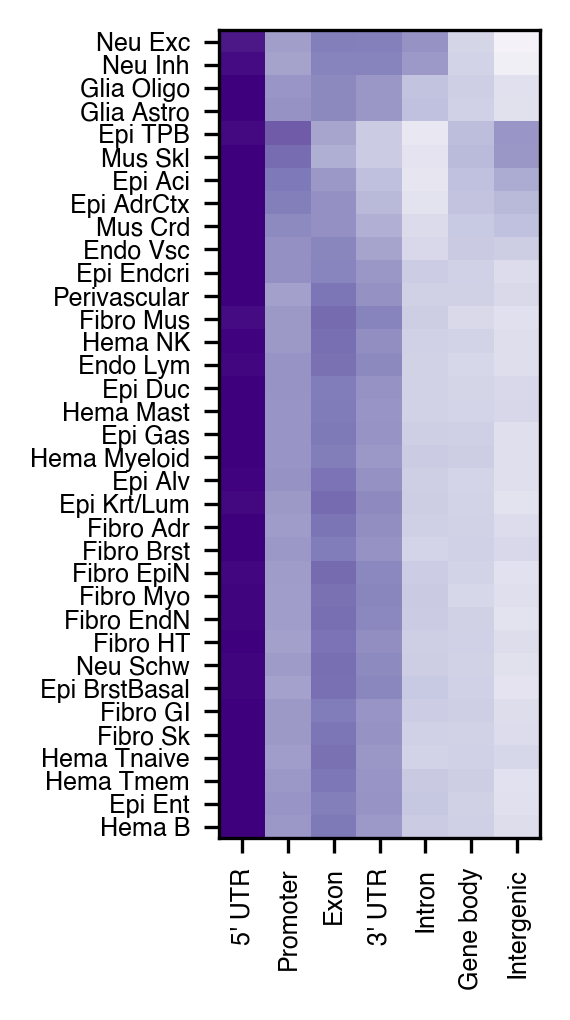

In [ ]:
corder = ['5utr', 'tss1k', 'exon', '3utr', 'intron', 'gene', 'intergenic']
xticklabels = ["5' UTR", "Promoter", "Exon", "3' UTR", "Intron", "Gene body", "Intergenic"]
fig, ax = plt.subplots(figsize=(2,3.5), dpi=300)

tmp = zscore(data[corder], axis=1).loc[leg_order]
ax.imshow(tmp, cmap='Purples_r', vmin=-2, vmax=2, aspect='auto')
# ax.set_xticks([])
xticks = np.arange(0, data.shape[1], 1)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=90, fontsize=6)
ax.set_yticks(np.arange(data.shape[0]))
ax.set_yticklabels(pd.Index(leg_order).map(L1_annot), fontsize=6)

fig.tight_layout()
fig.savefig(f'mCH_geneflank/L1_geneannot_mCH_heatmap.pdf', transparent=True)
